In [35]:
import sys
path_lock = False
if not path_lock:
    sys.path.append("../")
    path_lock = True
    
import numpy as np
import ffiting as ff

# Exponential

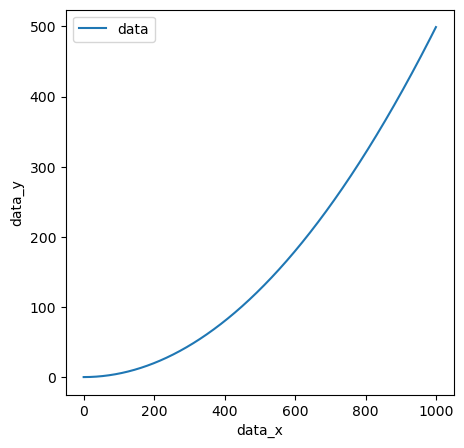

In [36]:
data_x = np.arange(0, 1000)
coeffs_poly = [0, 0, 0.0005]

model_data = ff.Generators.ranked_poly(coeffs_poly)
data_ideal = model_data(data_x)

ff.multi_plot(ff.PlotRequest(data_ideal,"data"))

## Use normal DSB

The balance was formed:


-a0 - a2 + c0

-H*a1 - H*a2*a3 + H*c1

-H**2*a2*a3**2/2 + H**2*c2

-H**3*a2*a3**3/6 + H**3*c3

...

'Expression generated:'

a0 + a1*x + a2*exp(a3*x)

'Coeffs: (-263018.833409537, -15.5116894296983, 263010.496124594, 5.91187386008185e-5)'

'Metrics:'

Residual SE: 2.640
Mean SE: 6.957
Linear Div: 1837.825
Standard Div: 149.867
Standard Err: 4.739
Determination Coeff: 1.000
Correlation Coeff: 1.000
Concordance Coeff: 1.000


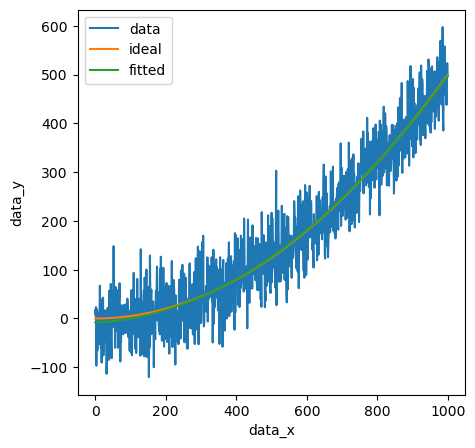

In [37]:
model = ff.Models.exponential(ff.FittingModes.DSB)
data_train = ff.apply_noise(data_ideal)
model_fitted = model.fit(data_train)
data_fitted = model_fitted(data_x)

display("Expression generated:", model.expr_sp)
display(f"Coeffs: {model_fitted.coeffs}")

display("Metrics:")
print(ff.get_metrics(data_fitted, data_ideal))

ff.multi_plot(ff.PlotRequest(data_train,"data"),
              ff.PlotRequest(data_ideal,"ideal"),
              ff.PlotRequest(data_fitted,"fitted"))

## Use coeffs calculated in Maple

'Metrics:'

Residual SE: 201.563
Mean SE: 40546.310
Linear Div: 148464.533
Standard Div: 13.366
Standard Err: 0.423
Determination Coeff: -225.960
Correlation Coeff: 0.968
Concordance Coeff: 0.114


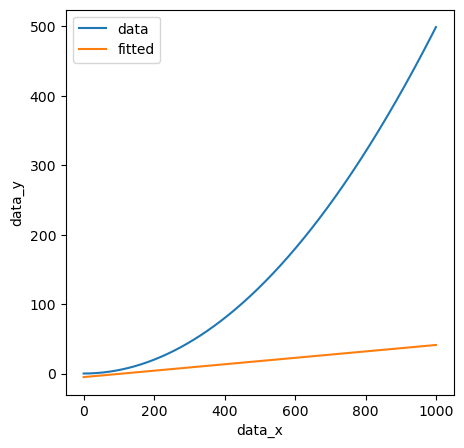

In [38]:
maple_coeffs = [-5.176117612, 0.04630251936, 0.03869580501, -0.1872036050]
def maple_model(x: float) -> float:
    return maple_coeffs[0] + maple_coeffs[1] * x + maple_coeffs[2] * np.exp(maple_coeffs[3] * x)

data_fitted = np.zeros(data_x.size)
for i in np.arange(data_x.size):
    data_fitted[i] = maple_model(data_x[i])

display("Metrics:")
print(ff.get_metrics(data_fitted, data_ideal))

ff.multi_plot(ff.PlotRequest(data_ideal,"data"),
              ff.PlotRequest(data_fitted,"fitted"))

## Use programmatic DSBI

Spectrum was formed:


-a0 - a2 + 1.43803738872902e-14

-H*a1 - H*a2*a3 - 3.98819738550357e-16*H

-H**2*a2*a3**2/2 + 0.000500000000000001*H**2

-H**3*a2*a3**3/6

...

'Expression generated:'

a0 + a1*x + a2*exp(a3*x)

'Coeffs: (5.57780000143808e-5 - a2, 0.000333999999999602, a2, 0)'

'Metrics:'

Residual SE: 223.364
Mean SE: 49791.769
Linear Div: 166249.861
Standard Div: 0.096
Standard Err: 0.003
Determination Coeff: -5356069.704
Correlation Coeff: 0.968
Concordance Coeff: 0.001


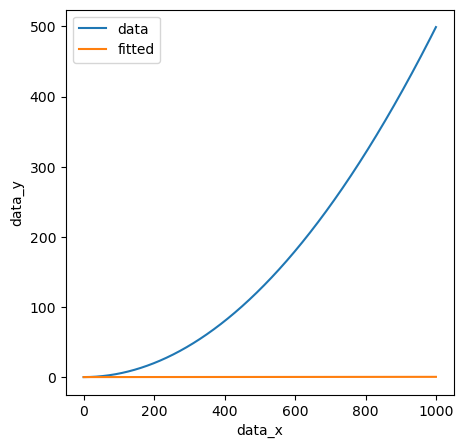

In [39]:
model = ff.Models.exponential(ff.FittingModes.DSBI)
model.options.rank = 4
model_fitted = model.fit(data_ideal)
data_fitted = model_fitted(data_x)

display("Expression generated:", model.expr_sp)
display(f"Coeffs: {model_fitted.coeffs}")

display("Metrics:")
print(ff.get_metrics(data_fitted, data_ideal))

ff.multi_plot(ff.PlotRequest(data_ideal,"data"),
              ff.PlotRequest(data_fitted,"fitted"))

Spectrum was formed:


-a0 - a2 - 10.0686569832842

-H*a1 - H*a2*a3 + 0.0619441020252185*H

-H**2*a2*a3**2/2 + 0.00042661374519232*H**2

-H**3*a2*a3**3/6 + 1.17939462467914e-8*H**3

...

'Expression generated:'

a0 + a1*x + a2*exp(a3*x)

'Coeffs: (-a2 - 10.0686093903792, 0.0622290859275915, a2, 0)'

'Metrics:'

Residual SE: 223.364
Mean SE: 49791.769
Linear Div: 166249.861
Standard Div: 0.096
Standard Err: 0.003
Determination Coeff: -5356069.704
Correlation Coeff: 0.968
Concordance Coeff: 0.001


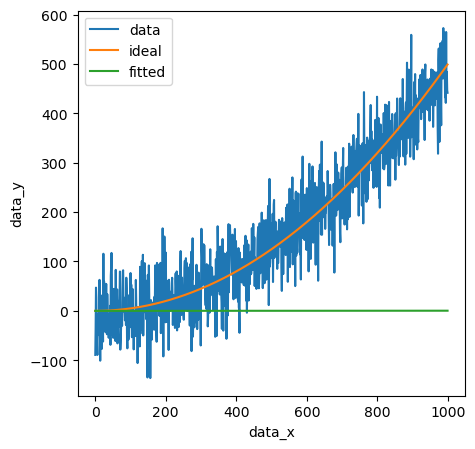

In [40]:
data_train = ff.apply_noise(data_ideal)
model_fitted = model.fit(data_train)

display("Expression generated:", model.expr_sp)
display(f"Coeffs: {model_fitted.coeffs}")

display("Metrics:")
print(ff.get_metrics(data_fitted, data_ideal))

ff.multi_plot(ff.PlotRequest(data_train,"data"),
              ff.PlotRequest(data_ideal,"ideal"),
              ff.PlotRequest(data_fitted,"fitted"))

# Trigonometric

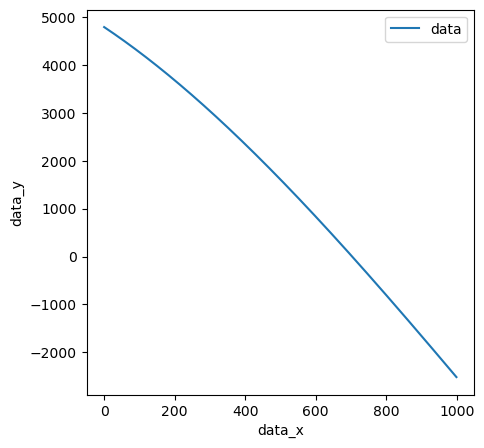

In [41]:
data_x = np.arange(0, 1000)
coeffs_poly = [4785.5, -4.9093, -0.0034, 10**-6]

model_data = ff.Generators.ranked_poly(coeffs_poly)
data_ideal = model_data(data_x)

ff.multi_plot(ff.PlotRequest(data_ideal,"data"))

## Use normal DSB

Polynomial model rank was raised to 5.
The balance was formed:


-a0 + c0

-H*a1*a2 + H*c1

H**2*a0*a1**2/2 + H**2*c2

H**3*c3

...

'Expression generated:'

a0*cos(a1*x) + a2*sin(a1*x)

'Coeffs: [ 4.78550000e+03 -1.19203991e-03  4.11840238e+03]'

'Metrics:'

Residual SE: 166.205
Mean SE: 27568.949
Linear Div: 104856.257
Standard Div: 2025.400
Standard Err: 64.049
Determination Coeff: 0.993
Correlation Coeff: 1.000
Concordance Coeff: 0.998


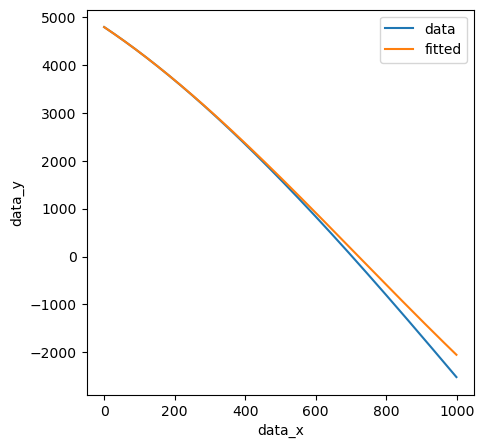

In [42]:
model = ff.Models.transcendental(ff.FittingModes.DSB)
model.options.raise_rank = True
model.options.numeric_optimize = False
model_fitted = model.fit(data_ideal)
data_fitted = model_fitted(data_x)

display("Expression generated:", model.expr_sp)
display(f"Coeffs: {model_fitted.coeffs}")

display("Metrics:")
print(ff.get_metrics(data_fitted, data_ideal))

ff.multi_plot(ff.PlotRequest(data_ideal,"data"),
              ff.PlotRequest(data_fitted,"fitted"))

Polynomial model rank was raised to 4.
The balance was formed:


-a0 + c0

-H*a1*a2 + H*c1

H**2*a0*a1**2/2 + H**2*c2

H**3*c3

...

'Expression generated:'

a0*cos(a1*x) + a2*sin(a1*x)

'Coeffs: [ 4.92691245e+03 -3.04951279e-04  2.08409081e+04]'

'Metrics:'

Residual SE: 166.205
Mean SE: 27568.949
Linear Div: 104856.257
Standard Div: 2025.400
Standard Err: 64.049
Determination Coeff: 0.993
Correlation Coeff: 1.000
Concordance Coeff: 0.998


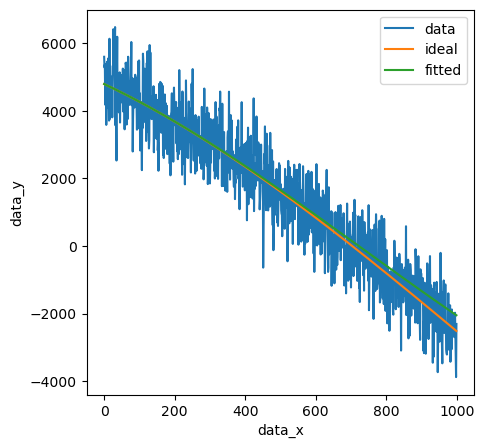

In [44]:
data_train = ff.apply_noise(data_ideal)
model_fitted = model.fit(data_train)

display("Expression generated:", model.expr_sp)
display(f"Coeffs: {model_fitted.coeffs}")

display("Metrics:")
print(ff.get_metrics(data_fitted, data_ideal))

ff.multi_plot(ff.PlotRequest(data_train,"data"),
              ff.PlotRequest(data_ideal,"ideal"),
              ff.PlotRequest(data_fitted,"fitted"))

## Use coeffs calculated in Maple

'Metrics:'

Residual SE: 165.209
Mean SE: 27239.475
Linear Div: 104005.450
Standard Div: 2026.041
Standard Err: 64.069
Determination Coeff: 0.993
Correlation Coeff: 1.000
Concordance Coeff: 0.998


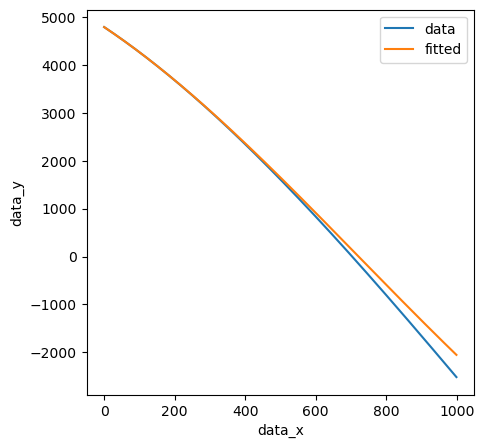

In [45]:
maple_coeffs = [4785.499998, 0.001192750974, -4115.942072]
def maple_model(x: float) -> float:
    return maple_coeffs[0] * np.cos(maple_coeffs[1] * x) + maple_coeffs[2] * np.sin(maple_coeffs[1] * x)

data_fitted = np.zeros(data_x.size)
for i in np.arange(data_x.size):
    data_fitted[i] = maple_model(data_x[i])

display("Metrics:")
print(ff.get_metrics(data_fitted, data_ideal))

ff.multi_plot(ff.PlotRequest(data_ideal,"data"),
              ff.PlotRequest(data_fitted,"fitted"))

## Use programmatic DSBI

Spectrum was formed:


4785.50000000001 - a0

-H*a1*a2 - 4.90930000000001*H

H**2*a0*a1**2/2 - 0.00339999999999996*H**2

9.99999999999959e-7*H**3

...

'Expression generated:'

a0*cos(a1*x) + a2*sin(a1*x)

'Coeffs: (4785.4999999874, 0, 4119.19952656537)'

'Metrics:'

Residual SE: 3967.636
Mean SE: 15710653.649
Linear Div: 3334329.000
Standard Div: 0.000
Standard Err: 0.000
Determination Coeff: -18993014839713403431084015747072.000
Correlation Coeff: -0.000
Concordance Coeff: 0.000


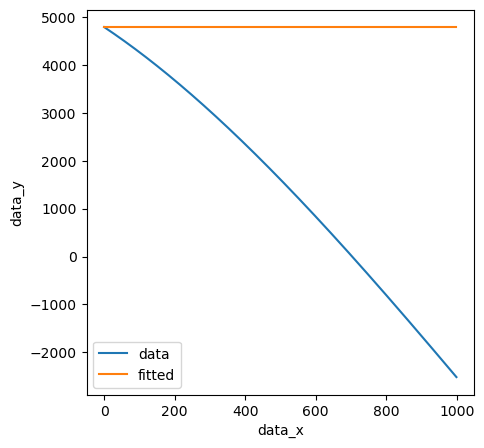

In [46]:
model = ff.Models.transcendental(ff.FittingModes.DSBI)
model.options.rank = 4
model_fitted = model.fit(data_ideal)
data_fitted = model_fitted(data_x)

display("Expression generated:", model.expr_sp)
display(f"Coeffs: {model_fitted.coeffs}")

display("Metrics:")
print(ff.get_metrics(data_fitted, data_ideal))

ff.multi_plot(ff.PlotRequest(data_ideal,"data"),
              ff.PlotRequest(data_fitted,"fitted"))

Spectrum was formed:


4880.60333421519 - a0

-H*a1*a2 - 5.40015815282643*H

H**2*a0*a1**2/2 - 0.00216003987255792*H**2

1.66696044935233e-8*H**3

...

'Expression generated:'

a0*cos(a1*x) + a2*sin(a1*x)

'Coeffs: (-1.49103627787875e-11, 32965856.2114179*I, -0.00029534567527644*I)'

'Metrics:'

Residual SE: 3967.636
Mean SE: 15710653.649
Linear Div: 3334329.000
Standard Div: 0.000
Standard Err: 0.000
Determination Coeff: -18993014839713403431084015747072.000
Correlation Coeff: -0.000
Concordance Coeff: 0.000


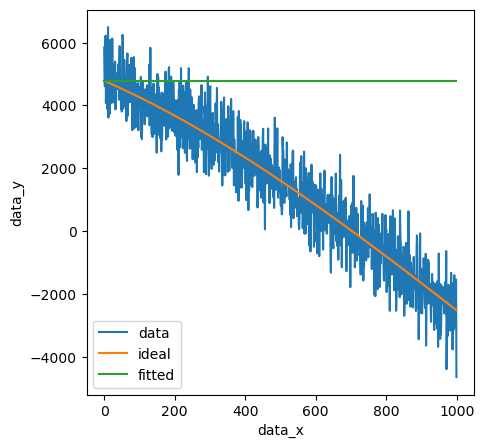

In [47]:
data_train = ff.apply_noise(data_ideal)
model_fitted = model.fit(data_train)

display("Expression generated:", model.expr_sp)
display(f"Coeffs: {model_fitted.coeffs}")

display("Metrics:")
print(ff.get_metrics(data_fitted, data_ideal))

ff.multi_plot(ff.PlotRequest(data_train,"data"),
              ff.PlotRequest(data_ideal,"ideal"),
              ff.PlotRequest(data_fitted,"fitted"))